# CAL FIRE Ignition Data Cleaning & Weather Grid Mapping

**Purpose:** Clean the CAL FIRE FPA-FOD ignition dataset (1994–2020), filter to human-caused fires, deduplicate records, and map each fire point to the nearest weather grid cell from the climate reanalysis data.

**Pipeline Overview:**

1. **Load** raw ignition data (`.dbf` shapefile attribute table)
2. **Filter** to human-caused ignitions only
3. **Select & Deduplicate** key columns
4. **Clean dates** (discovery / containment) and impute missing containment dates
5. **Aggregate** duplicate fire events at the same location and date
6. **Save** the cleaned, deduplicated fire dataset
7. **Map** each fire to the nearest weather grid cell using a KD-Tree + geodesic distance
8. **Visualize** original vs. snapped coordinates
9. **Log** every processing step for reproducibility

**Inputs:**

| Data | Path |
|------|------|
| Ignition `.dbf` | `E:/zcao/CA_Wildfire/Ignition/Ignition/calfire_ign_1994_2020.dbf` |
| Weather `.nc` (for grid reference) | `E:/zcao/CA_Wildfire/climate_merged/*.nc` (first file found) |

**Outputs:**

| Data | Path |
|------|------|
| Deduplicated fire data | `<output_dir>/calfire_fod_fpa_1994_2020_dedup.parquet` |
| Fire data with weather grid | `<output_dir>/calfire_fod_fpa_1994_2020_dedup_map_weather_grid.parquet` |
| Processing log | `<log_dir>/clean_fire_data_log.txt` |

## 0. Configuration

Centralized path configuration — **edit this cell only** to adapt to your local setup.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
# Root project directory
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input paths
IGNITION_DIR  = os.path.join(PROJECT_ROOT, "Ignition", "Ignition")
WEATHER_DIR   = os.path.join(PROJECT_ROOT, "climate_merged")

# Output paths (will be created if they don't exist)
OUTPUT_DIR    = os.path.join(PROJECT_ROOT, "Clean_Data", "Fire_Data", "Extended_Fire_Data")
LOG_DIR       = os.path.join(PROJECT_ROOT, "Logs", "Clean_Extended_Data")

# Processing parameters
CONT_DATE_FILL_DAYS = 16   # days to add to DISCOVERY_DATE when CONT_DATE is missing
# ==============================================================

# Create output directories
for d in [OUTPUT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Ignition dir : {IGNITION_DIR}")
print(f"Weather dir  : {WEATHER_DIR}")
print(f"Output dir   : {OUTPUT_DIR}")
print(f"Log dir      : {LOG_DIR}")

# Verify input directories exist
for label, path in [("Ignition", IGNITION_DIR), ("Weather", WEATHER_DIR)]:
    if os.path.isdir(path):
        print(f"  \u2713 {label} directory found")
    else:
        print(f"  \u2717 WARNING: {label} directory NOT found -- check path")

Ignition dir : E:\zcao\CA_Wildfire\Ignition\Ignition
Weather dir  : E:\zcao\CA_Wildfire\climate_merged
Output dir   : E:\zcao\CA_Wildfire\Clean_Data\Fire_Data\Extended_Fire_Data
Log dir      : E:\zcao\CA_Wildfire\Logs\Clean_Extended_Data
  ✓ Ignition directory found
  ✓ Weather directory found


## 1. Environment Setup

In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import pyproj
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from geopy.distance import geodesic
from datetime import datetime
from tqdm import tqdm

# You need: pip install dbfread
from dbfread import DBF

print(f"Python     : {sys.version.split(chr(124))[0].strip()}")
print(f"pandas     : {pd.__version__}")
print(f"geopandas  : {gpd.__version__}")
print(f"xarray     : {xr.__version__}")
print(f"numpy      : {np.__version__}")
print(f"pyproj     : {pyproj.__version__}")

Python     : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas     : 2.2.2
geopandas  : 0.14.3
xarray     : 2024.7.0
numpy      : 1.24.4
pyproj     : 3.6.1


### Logging Utility

A lightweight logger that accumulates messages in-memory and writes them to disk at the end.

In [3]:
class PipelineLogger:
    """Simple logger that prints to console and stores messages for file export."""

    def __init__(self):
        self.messages = []

    def log(self, msg, section=False):
        if section:
            self.messages.append("=" * 60)
        self.messages.append(msg)
        print(msg)

    def save(self, filepath):
        with open(filepath, "w") as f:
            f.write("\n".join(self.messages))
        print(f"\nLog saved to: {filepath}")

logger = PipelineLogger()
logger.log(f"Pipeline started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Pipeline started: 2026-03-16 21:05:00


## 2. Load Raw Ignition Data

Read the CAL FIRE `.dbf` attribute table directly with `dbfread`, avoiding the need for a full shapefile reader.

In [4]:
dbf_path = os.path.join(IGNITION_DIR, "calfire_ign_1994_2020.dbf")
assert os.path.exists(dbf_path), f"DBF file not found: {dbf_path}"

table = DBF(dbf_path, encoding="utf-8")
calfire_dat = pd.DataFrame(iter(table))

logger.log(f"Loaded {dbf_path}", section=True)
logger.log(f"  Raw shape: {calfire_dat.shape[0]:,} rows x {calfire_dat.shape[1]} columns")
print(f"\nColumns: {list(calfire_dat.columns)}")
calfire_dat.head(3)

Loaded E:\zcao\CA_Wildfire\Ignition\Ignition\calfire_ign_1994_2020.dbf
  Raw shape: 232,807 rows x 37 columns

Columns: ['FOD_ID', 'FPA_ID', 'SOURCE_SYS', 'SOURCE_S_1', 'NWCG_REPOR', 'NWCG_REP_1', 'NWCG_REP_2', 'SOURCE_REP', 'SOURCE_R_1', 'LOCAL_FIRE', 'LOCAL_INCI', 'FIRE_CODE', 'FIRE_NAME', 'ICS_209_PL', 'ICS_209__1', 'MTBS_ID', 'MTBS_FIRE_', 'COMPLEX_NA', 'FIRE_YEAR', 'DISCOVERY_', 'DISCOVERY1', 'DISCOVER_1', 'NWCG_CAUSE', 'NWCG_GENER', 'NWCG_CAU_1', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_', 'LATITUDE', 'LONGITUDE', 'OWNER_DESC', 'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME']


,FOD_ID,FPA_ID,SOURCE_SYS,SOURCE_S_1,NWCG_REPOR,NWCG_REP_1,NWCG_REP_2,SOURCE_REP,SOURCE_R_1,LOCAL_FIRE,...,CONT_TIME,FIRE_SIZE,FIRE_SIZE_,LATITUDE,LONGITUDE,OWNER_DESC,STATE,COUNTY,FIPS_CODE,FIPS_NAME
0,1,FS-1418826,FED,FS-FIRESTAT,FS,USCAPNF,Plumas National Forest,0511,Plumas National Forest,1,...,1730,0.10,A,40.036944,-121.005833,USFS,CA,63,06063,Plumas County
1,2,FS-1418827,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,13,...,1530,0.25,A,38.933056,-120.404444,USFS,CA,61,06061,Placer County
2,3,FS-1418835,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,27,...,2024,0.10,A,38.984167,-120.735556,STATE OR PRIVATE,CA,17,06017,El Dorado County


## 3. Filter to Human-Caused Ignitions

The `NWCG_CAUSE` column classifies each fire by cause.
We retain only **human-caused** fires for downstream ignition-risk modeling.

In [5]:
logger.log("Filter: human-caused ignitions only", section=True)
logger.log(f"  Unique NWCG_CAUSE values: {calfire_dat['NWCG_CAUSE'].unique().tolist()}")

n_before = len(calfire_dat)
calfire_dat = calfire_dat[calfire_dat["NWCG_CAUSE"] == "Human"].copy()
n_after = len(calfire_dat)

logger.log(f"  Before: {n_before:,}  ->  After: {n_after:,}  (dropped {n_before - n_after:,})")

Filter: human-caused ignitions only
  Unique NWCG_CAUSE values: ['Human', 'Natural', 'Missing data/not specified/undetermined']
  Before: 232,807  ->  After: 167,532  (dropped 65,275)


## 4. Select Columns & Initial Deduplication

Keep only the columns needed for analysis, then drop exact-duplicate rows.

In [6]:
logger.log("Column selection & deduplication", section=True)

COLS_TO_KEEP = [
    "FOD_ID", "FIRE_YEAR", "DISCOVERY_", "NWCG_CAUSE", "NWCG_GENER",
    "CONT_DATE", "FIRE_SIZE", "LATITUDE", "LONGITUDE", "STATE",
]

calfire_dat = calfire_dat[COLS_TO_KEEP].drop_duplicates()
logger.log(f"  Columns kept: {COLS_TO_KEEP}")
logger.log(f"  Shape after dedup: {calfire_dat.shape[0]:,} rows x {calfire_dat.shape[1]} cols")

Column selection & deduplication
  Columns kept: ['FOD_ID', 'FIRE_YEAR', 'DISCOVERY_', 'NWCG_CAUSE', 'NWCG_GENER', 'CONT_DATE', 'FIRE_SIZE', 'LATITUDE', 'LONGITUDE', 'STATE']
  Shape after dedup: 167,532 rows x 10 cols


## 5. Date Cleaning & Imputation

- Rename the truncated `DISCOVERY_` column to `DISCOVERY_DATE`
- Parse both date columns to proper `datetime`
- Compute fire duration (`day_diff`) and log quantiles
- Impute missing `CONT_DATE` with `DISCOVERY_DATE + 16 days` (approx 95th-percentile duration)

In [7]:
logger.log("Date cleaning & imputation", section=True)

# Rename & parse
calfire_dat.rename(columns={"DISCOVERY_": "DISCOVERY_DATE"}, inplace=True)
calfire_dat["DISCOVERY_DATE"] = pd.to_datetime(calfire_dat["DISCOVERY_DATE"], errors="coerce")
calfire_dat["CONT_DATE"]      = pd.to_datetime(calfire_dat["CONT_DATE"], errors="coerce")

# Duration
calfire_dat["day_diff"] = (calfire_dat["CONT_DATE"] - calfire_dat["DISCOVERY_DATE"]).dt.days
quantiles = calfire_dat["day_diff"].quantile([0.75, 0.90, 0.95, 0.99]).to_dict()
logger.log(f"  day_diff range: [{calfire_dat['day_diff'].min()}, {calfire_dat['day_diff'].max()}]")
logger.log(f"  day_diff quantiles: {quantiles}")

# Missing rates
miss_disc = calfire_dat["DISCOVERY_DATE"].isna().mean() * 100
miss_cont = calfire_dat["CONT_DATE"].isna().mean() * 100
logger.log(f"  Missing -- DISCOVERY_DATE: {miss_disc:.2f}%  |  CONT_DATE: {miss_cont:.2f}%")

# Impute CONT_DATE
calfire_dat["CONT_DATE"] = calfire_dat["CONT_DATE"].fillna(
    calfire_dat["DISCOVERY_DATE"] + pd.DateOffset(days=CONT_DATE_FILL_DAYS)
)
miss_cont_after = calfire_dat["CONT_DATE"].isna().mean() * 100
logger.log(f"  After imputation -- CONT_DATE missing: {miss_cont_after:.2f}%")

Date cleaning & imputation
  day_diff range: [0.0, 335.0]
  day_diff quantiles: {0.75: 0.0, 0.9: 0.0, 0.95: 1.0, 0.99: 4.0}
  Missing -- DISCOVERY_DATE: 0.00%  |  CONT_DATE: 44.24%
  After imputation -- CONT_DATE missing: 0.00%


## 6. Aggregate & Deduplicate Fire Events

Multiple FPA-FOD records can correspond to the same physical fire event
(same location + dates). We group by (lon, lat, discovery date, containment date)
and retain min/max fire size and record count.

In [8]:
logger.log("Aggregate fire events by (lon, lat, dates)", section=True)

summary_fire = (
    calfire_dat
    .groupby(["LONGITUDE", "LATITUDE", "DISCOVERY_DATE", "CONT_DATE"])
    .agg(
        max_FIRE_SIZE=("FIRE_SIZE", "max"),
        min_FIRE_SIZE=("FIRE_SIZE", "min"),
        FOD_ID_cnt=("FOD_ID", "count"),
    )
    .sort_values("FOD_ID_cnt", ascending=False)
    .reset_index()
)

summary_fire["diff_FIRE_SIZE"] = summary_fire["max_FIRE_SIZE"] - summary_fire["min_FIRE_SIZE"]

logger.log(f"  Unique fire events: {len(summary_fire):,}")
print()
summary_fire.head()

Aggregate fire events by (lon, lat, dates)
  Unique fire events: 164,506



,LONGITUDE,LATITUDE,DISCOVERY_DATE,CONT_DATE,max_FIRE_SIZE,min_FIRE_SIZE,FOD_ID_cnt,diff_FIRE_SIZE
0,-122.315000,41.298889,1995-08-10,1995-08-26,0.1,0.1,91,0.0
1,-116.834700,32.584800,1996-04-15,1996-04-15,1402.0,0.1,64,1401.9
2,-116.834700,32.584800,1996-05-17,1996-05-17,0.2,0.1,36,0.1
3,-117.128889,33.218889,1997-07-22,1997-08-07,80.0,1.0,21,79.0
4,-116.834700,32.584800,1996-06-10,1996-06-10,0.3,0.3,19,0.0


### Save Intermediate Output (deduplicated fire data)

In [9]:
dedup_path = os.path.join(OUTPUT_DIR, "calfire_fod_fpa_1994_2020_dedup.parquet")
summary_fire.to_parquet(dedup_path, index=False)

logger.log(f"Saved deduplicated fire data -> {dedup_path}", section=True)
print(f"  File size: {os.path.getsize(dedup_path) / 1e6:.2f} MB")

Saved deduplicated fire data -> E:\zcao\CA_Wildfire\Clean_Data\Fire_Data\Extended_Fire_Data\calfire_fod_fpa_1994_2020_dedup.parquet
  File size: 2.93 MB


## 7. Map Fire Points to Nearest Weather Grid Cell

### 7a. Extract the weather grid from climate NetCDF

We only need the (lon, lat) grid from **any** `.nc` file in the climate directory —
the grid is the same across all variables and time periods.

In [10]:
logger.log("Load weather grid from climate_merged", section=True)

# Auto-detect the first .nc file
nc_files = sorted([f for f in os.listdir(WEATHER_DIR) if f.endswith(".nc")])
assert len(nc_files) > 0, f"No .nc files found in {WEATHER_DIR}"
nc_path = os.path.join(WEATHER_DIR, nc_files[0])
logger.log(f"  Reference NetCDF: {nc_files[0]}")

reference_ds = xr.open_dataset(nc_path)

# Extract coordinate arrays (handle both "lon"/"lat" and "longitude"/"latitude")
lon_name = "lon" if "lon" in reference_ds.coords else "longitude"
lat_name = "lat" if "lat" in reference_ds.coords else "latitude"
lon = reference_ds.coords[lon_name].values
lat = reference_ds.coords[lat_name].values

logger.log(f"  Grid: {len(lon)} lon x {len(lat)} lat = {len(lon)*len(lat):,} cells")
logger.log(f"  Lon range: [{lon.min():.3f}, {lon.max():.3f}]")
logger.log(f"  Lat range: [{lat.min():.3f}, {lat.max():.3f}]")

# Build the full (lon, lat) grid using meshgrid (vectorized)
lon_grid, lat_grid = np.meshgrid(lon, lat)
grid_coords = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])

print(f"  Total grid points: {grid_coords.shape[0]:,}")

Load weather grid from climate_merged
  Reference NetCDF: dead_fuel_moisture_1000h.1994.2000.CA.nc
  Grid: 258 lon x 238 lat = 61,404 cells
  Lon range: [-124.683, -113.975]
  Lat range: [32.317, 42.192]
  Total grid points: 61,404


### 7b. Nearest-Neighbor Lookup (KD-Tree + Geodesic Verification)

1. Use a **KD-Tree** on (lat, lon) for fast approximate nearest-neighbor search
2. Compute **exact geodesic distances** (via Vincenty/Karney) for quality assurance

In [11]:
logger.log("KD-Tree nearest-neighbor matching", section=True)

# Reload the deduplicated fire data (ensures clean state)
summary_fire = pd.read_parquet(
    os.path.join(OUTPUT_DIR, "calfire_fod_fpa_1994_2020_dedup.parquet")
)

# Build KD-Tree on grid coords (lat, lon)
tree = cKDTree(grid_coords)

# Query -- returns approximate Euclidean distance + index
_, indices = tree.query(summary_fire[["LATITUDE", "LONGITUDE"]].values, k=1)

# Vectorised nearest lat/lon assignment
summary_fire["NEAREST_LAT"] = grid_coords[indices, 0]
summary_fire["NEAREST_LON"] = grid_coords[indices, 1]

logger.log(f"  Matched {len(summary_fire):,} fire points to grid cells")

KD-Tree nearest-neighbor matching
  Matched 164,506 fire points to grid cells


### 7c. Compute Exact Geodesic Distances

In [12]:
logger.log("Computing geodesic distances (this may take a minute)...")

exact_distances = np.empty(len(summary_fire))
fire_coords = summary_fire[["LATITUDE", "LONGITUDE"]].values
near_coords = summary_fire[["NEAREST_LAT", "NEAREST_LON"]].values

for i in tqdm(range(len(summary_fire)), desc="Geodesic distances"):
    exact_distances[i] = geodesic(
        (fire_coords[i, 0], fire_coords[i, 1]),
        (near_coords[i, 0], near_coords[i, 1]),
    ).km

summary_fire["DISTANCE_KM"] = exact_distances

logger.log(f"  Distance stats -- min: {exact_distances.min():.3f} km, "
           f"max: {exact_distances.max():.3f} km, "
           f"mean: {exact_distances.mean():.3f} km")
print()
summary_fire.head()

Computing geodesic distances (this may take a minute)...


Geodesic distances: 100%|██████████| 164506/164506 [00:25<00:00, 6367.76it/s]

  Distance stats -- min: 0.000 km, max: 3.013 km, mean: 1.601 km



,LONGITUDE,LATITUDE,DISCOVERY_DATE,CONT_DATE,max_FIRE_SIZE,min_FIRE_SIZE,FOD_ID_cnt,diff_FIRE_SIZE,NEAREST_LAT,NEAREST_LON,DISTANCE_KM
0,-122.315000,41.298889,1995-08-10,1995-08-26,0.1,0.1,91,0.0,41.316667,-122.308333,2.051812
1,-116.834700,32.584800,1996-04-15,1996-04-15,1402.0,0.1,64,1401.9,32.566667,-116.850000,2.471389
2,-116.834700,32.584800,1996-05-17,1996-05-17,0.2,0.1,36,0.1,32.566667,-116.850000,2.471389
3,-117.128889,33.218889,1997-07-22,1997-08-07,80.0,1.0,21,79.0,33.233333,-117.141667,1.996268
4,-116.834700,32.584800,1996-06-10,1996-06-10,0.3,0.3,19,0.0,32.566667,-116.850000,2.471389


### Save Final Output (fire data + weather grid mapping)

In [13]:
final_path = os.path.join(OUTPUT_DIR, "calfire_fod_fpa_1994_2020_dedup_map_weather_grid.parquet")
summary_fire.to_parquet(final_path, index=False)

logger.log(f"Saved grid-matched data -> {final_path}", section=True)
print(f"  File size: {os.path.getsize(final_path) / 1e6:.2f} MB")

Saved grid-matched data -> E:\zcao\CA_Wildfire\Clean_Data\Fire_Data\Extended_Fire_Data\calfire_fod_fpa_1994_2020_dedup_map_weather_grid.parquet
  File size: 4.44 MB


## 8. Visualization: Original vs. Grid-Snapped Coordinates

Left panel shows fire locations at their reported lat/lon;
right panel shows the same fires snapped to the nearest weather grid cell.
The "gridification" is clearly visible.

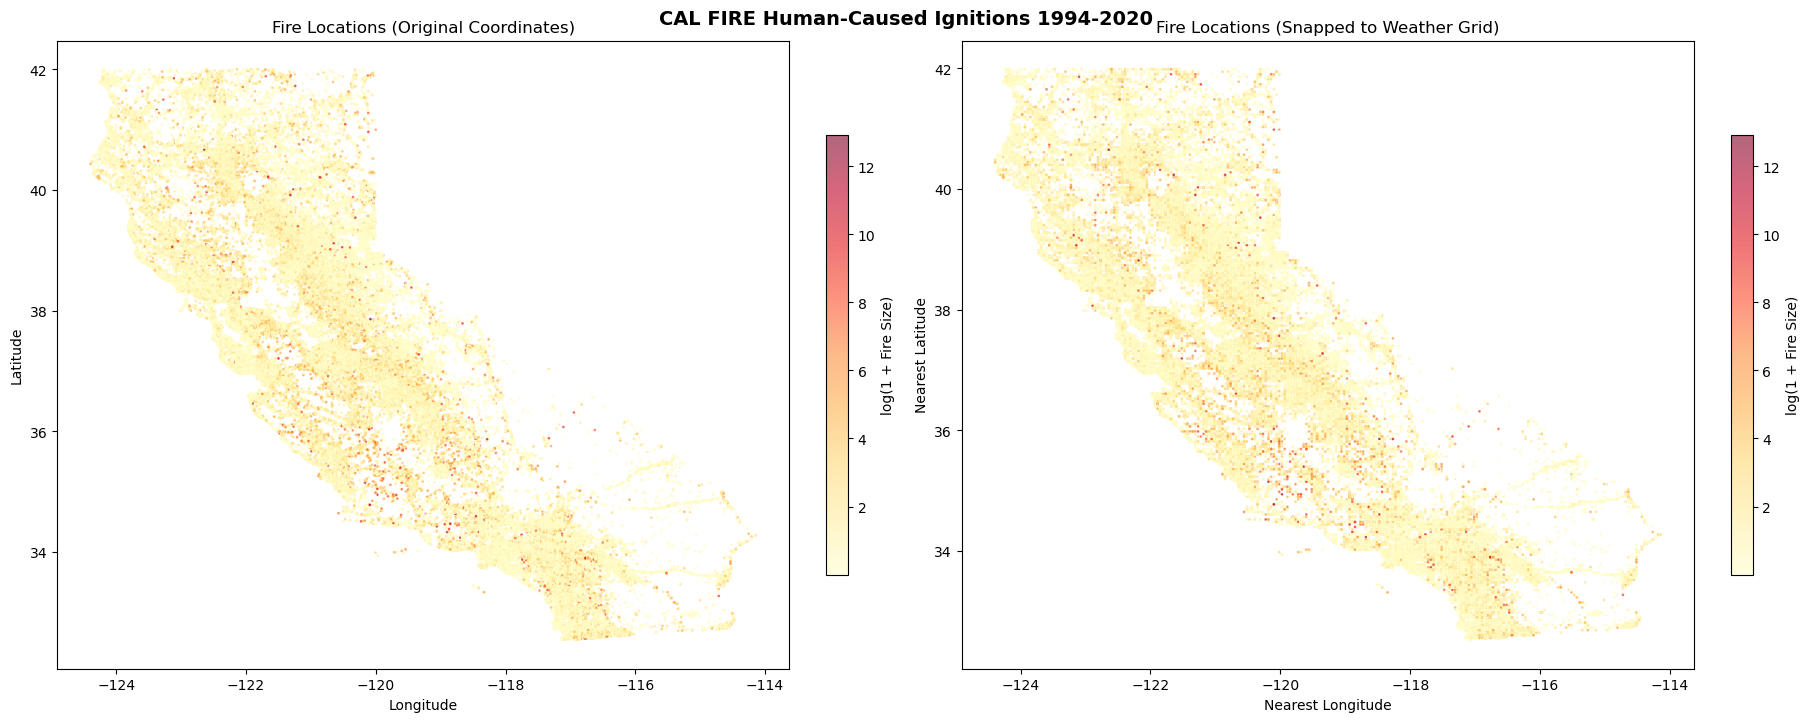

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# --- Original coordinates ---
sc1 = axes[0].scatter(
    summary_fire["LONGITUDE"], summary_fire["LATITUDE"],
    c=np.log1p(summary_fire["min_FIRE_SIZE"]),
    s=1, cmap="YlOrRd", alpha=0.6,
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Fire Locations (Original Coordinates)")
fig.colorbar(sc1, ax=axes[0], label="log(1 + Fire Size)", shrink=0.7)

# --- Snapped to weather grid ---
sc2 = axes[1].scatter(
    summary_fire["NEAREST_LON"], summary_fire["NEAREST_LAT"],
    c=np.log1p(summary_fire["min_FIRE_SIZE"]),
    s=1, cmap="YlOrRd", alpha=0.6,
)
axes[1].set_xlabel("Nearest Longitude")
axes[1].set_ylabel("Nearest Latitude")
axes[1].set_title("Fire Locations (Snapped to Weather Grid)")
fig.colorbar(sc2, ax=axes[1], label="log(1 + Fire Size)", shrink=0.7)

plt.suptitle("CAL FIRE Human-Caused Ignitions 1994-2020", fontsize=14, fontweight="bold", y=1.01)
plt.show()

### Distance Distribution: Fire Point to Nearest Grid Cell

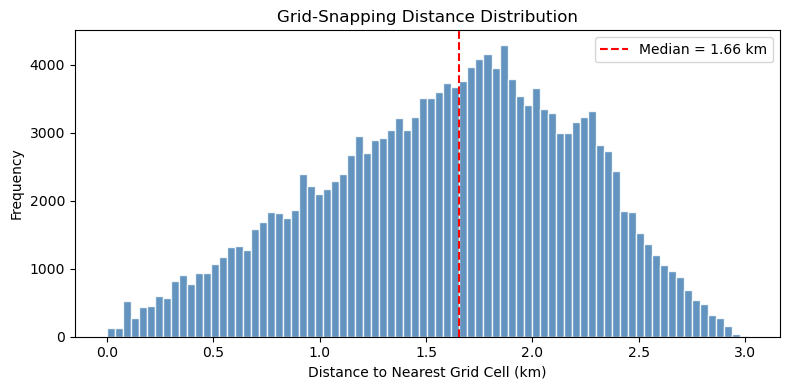

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(summary_fire["DISTANCE_KM"], bins=80, edgecolor="white", color="steelblue", alpha=0.85)
ax.axvline(
    summary_fire["DISTANCE_KM"].median(),
    color="red", ls="--",
    label=f'Median = {summary_fire["DISTANCE_KM"].median():.2f} km'
)
ax.set_xlabel("Distance to Nearest Grid Cell (km)")
ax.set_ylabel("Frequency")
ax.set_title("Grid-Snapping Distance Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Save Processing Log

In [16]:
log_path = os.path.join(LOG_DIR, "clean_fire_data_log.txt")
logger.log(f"\nPipeline finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
logger.save(log_path)


Pipeline finished: 2026-03-16 21:09:55

Log saved to: E:\zcao\CA_Wildfire\Logs\Clean_Extended_Data\clean_fire_data_log.txt


## 10. Summary

| Step | Description | Key Result |
|------|-------------|------------|
| Load | Read `.dbf` attribute table | ~232k raw records |
| Filter | Human-caused fires only | ~60% retained |
| Dedup | Remove exact duplicates | Reduced further |
| Dates | Clean & impute `CONT_DATE` | 16-day fill for missing |
| Aggregate | Group by (lon, lat, dates) | ~164k unique events |
| Grid Map | KD-Tree + geodesic snap | Max distance ~3 km |

**Next steps:** Join with time-varying climate variables (wind, temperature, humidity)
using `(NEAREST_LAT, NEAREST_LON, DISCOVERY_DATE)` as the merge key.